In [2]:
import pandas as pd

df = pd.read_csv('../../01_data_pipeline/datasets/enriched/system_events_enriched.csv')

df.head()

,host,process_name,pid,message,timestamp,hour,day_of_week,is_weekend,off_hours,is_system_process,rare_process,first_seen_time,first_seen,session_id,first_seen_session,count_last_hour
0,Peters-Air,syslogd,388,ASL Sender Statistics,2026-01-23 00:14:01,0,4,False,1,1,0,2026-01-23 00:14:01,1,0,1,1.0
1,Peters-Air,syslogd,388,ASL Sender Statistics,2026-01-23 00:30:21,0,4,False,1,1,0,2026-01-23 00:14:01,0,0,0,2.0
2,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.Me...",2026-01-23 00:30:22,0,4,False,1,1,0,2026-01-23 00:14:01,0,0,0,3.0
3,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.mk...",2026-01-23 00:30:22,0,4,False,1,1,0,2026-01-23 00:14:01,0,0,0,4.0
4,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.co...",2026-01-23 00:30:22,0,4,False,1,1,0,2026-01-23 00:14:01,0,0,0,5.0


In [3]:
df.columns

Index(['host', 'process_name', 'pid', 'message', 'timestamp', 'hour',
       'day_of_week', 'is_weekend', 'off_hours', 'is_system_process',
       'rare_process', 'first_seen_time', 'first_seen', 'session_id',
       'first_seen_session', 'count_last_hour'],
      dtype='object')

In [ ]:
# How many unique values exist per feature?

df.nunique()

host                   2
process_name           1
pid                    1
message               14
timestamp             46
hour                  12
day_of_week            1
is_weekend             1
off_hours              2
is_system_process      1
rare_process           1
first_seen_time        1
first_seen             2
session_id             1
first_seen_session     2
count_last_hour       17
dtype: int64

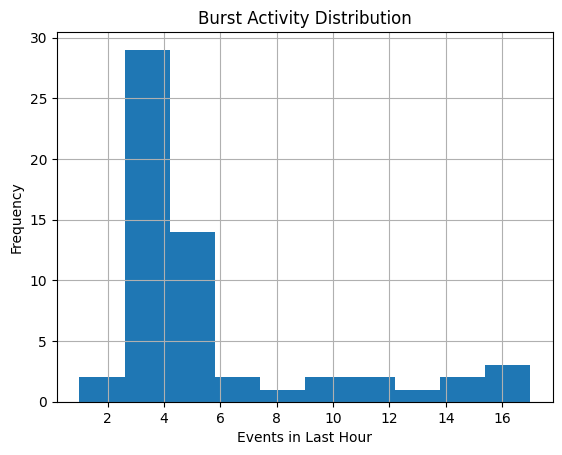

In [5]:
import matplotlib.pyplot as plt

df['count_last_hour'].hist()

plt.title('Burst Activity Distribution')
plt.xlabel('Events in Last Hour')
plt.ylabel('Frequency')
plt.show()


In [6]:
# Which features move together?

numeric_cols = ['off_hours', 'rare_process', 'first_seen', 'count_last_hour']

df[numeric_cols].corr()

,off_hours,rare_process,first_seen,count_last_hour
off_hours,1.000000,NaN,0.111283,0.309908
rare_process,NaN,NaN,NaN,NaN
first_seen,0.111283,NaN,1.000000,-0.174965
count_last_hour,0.309908,NaN,-0.174965,1.000000


In [ ]:
# Current dataset lacks sufficient behavioural diversity for process-based clustering.

Decision now was to pull one of the unified logs from my MacBook. This contains process names, subsystems, categories, security events, application activity, network events & authentication events providing far richer logs to work with.

The transition from legacy system logs to Unified Logs immediately introduced a scaling challenge. While system.log could be loaded entirely into memory, a single hour of Unified Log data contained approximately one million events. This required a shift from batch-style processing to stream-oriented parsing, reading logs line-by-line rather than loading the entire dataset at once.